# Exoplanet Host Prediction — EDA and Modeling

This notebook explores stellar properties, creates reusable engineered features, compares classification models, and selects XGBoost as the final model for predicting whether a star is likely to be an exoplanet host.

Main target: `exoplanet_host`  
Main selected model: `XGBoost`  
Important note: this model estimates similarity to known exoplanet-host stars. It does not confirm that a star truly has planets.


## 1. Imports and configuration

In [ ]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

set_config(display="diagram")
pd.set_option("display.max_columns", None)
%matplotlib inline

# Make local utilities importable when this notebook is opened from the notebooks folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.exoplanet_features import (
    CATEGORICAL_FEATURES,
    FINAL_FEATURES,
    NUMERIC_FEATURES,
    engineer_features,
    prepare_model_input
)


## 2. Load data

Update `DATA_PATH` if your file is in a different location.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "Labeled_Stars.csv"

raw_stars = pd.read_csv(DATA_PATH, index_col=False)
raw_stars.head()


,gaia_dr3_id,st_teff,st_rad,st_mass,st_met,st_logg,st_lum,st_age,sy_dist,sy_plx,is_exoplanet_host
0,2086441721667415424,4971.0,0.750,0.790,-0.05,4.600,-0.53589,4.27000,820.905,1.190750,1
1,2052381737659167488,5705.0,0.905,0.943,-0.06,4.499,-0.07942,9.95319,1061.770,0.914400,1
2,2100418850915010432,6022.0,1.230,1.120,0.07,4.310,0.39085,4.17000,493.175,1.999070,1
3,2078049767888231936,6747.0,1.810,1.490,0.08,4.090,0.71041,1.62000,1318.050,0.730368,1
4,2136207095405014912,5446.0,0.821,0.824,-0.20,4.525,-0.39819,7.20000,962.888,1.010300,1


## 3. Basic cleaning and feature engineering




In [3]:
stars_df = raw_stars.drop(columns=["gaia_dr3_id"], errors="ignore").copy()
stars_df = engineer_features(stars_df)

print(f"Dataset shape after feature engineering: {stars_df.shape}")
stars_df.info()


Dataset shape after feature engineering: (24864, 20)
<class 'pandas.DataFrame'>
RangeIndex: 24864 entries, 0 to 24863
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   star_temperature_kelvin      24864 non-null  float64
 1   star_radius_solar_units      24864 non-null  float64
 2   star_mass_solar_units        24864 non-null  float64
 3   star_metallicity             24864 non-null  float64
 4   surface_gravity_log          24864 non-null  float64
 5   star_luminosity_log          24864 non-null  float64
 6   star_age_billion_years       24864 non-null  float64
 7   distance_parsecs             24864 non-null  float64
 8   parallax_milliarcsec         24864 non-null  float64
 9   exoplanet_host               24864 non-null  int64  
 10  star_radius_solar_units_log  24864 non-null  float64
 11  star_mass_solar_units_log    24864 non-null  float64
 12  distance_parsecs_log         248

In [4]:
stars_df.head()

,star_temperature_kelvin,star_radius_solar_units,star_mass_solar_units,star_metallicity,surface_gravity_log,star_luminosity_log,star_age_billion_years,distance_parsecs,parallax_milliarcsec,exoplanet_host,star_radius_solar_units_log,star_mass_solar_units_log,distance_parsecs_log,parallax_milliarcsec_log,stellar_type,stellar_density,sun_similarity,hz_inner,hz_outer,hz_width
0,4971.0,0.750,0.790,-0.05,4.600,-0.53589,4.27000,820.905,1.190750,1,0.559616,0.582216,6.711625,0.784244,K,1.872593,0.8421,0.514468,0.741169,0.226700
1,5705.0,0.905,0.943,-0.06,4.499,-0.07942,9.95319,1061.770,0.914400,1,0.644482,0.664233,6.968634,0.649404,G,1.272231,0.9525,0.870149,1.253580,0.383431
2,6022.0,1.230,1.120,0.07,4.310,0.39085,4.17000,493.175,1.999070,1,0.802002,0.751416,6.202890,1.098302,F,0.601870,0.8991,1.495301,2.154205,0.658904
3,6747.0,1.810,1.490,0.08,4.090,0.71041,1.62000,1318.050,0.730368,1,1.033184,0.912283,7.184667,0.548334,F,0.251276,0.6569,2.160273,3.112197,0.951924
4,5446.0,0.821,0.824,-0.20,4.525,-0.39819,7.20000,962.888,1.010300,1,0.599386,0.601032,6.870975,0.698284,G,1.489010,0.8660,0.602849,0.868494,0.265645


In [5]:
stars_df.describe().T

,count,mean,std,min,25%,50%,75%,max
star_temperature_kelvin,24864.0,5973.115397,2295.151488,2.566000e+03,3904.452820,5650.803955,6783.740601,11727.958984
star_radius_solar_units,24864.0,17.492195,47.891604,1.192000e-01,0.778875,1.297650,2.500700,840.911072
star_mass_solar_units,24864.0,1.392396,0.777743,8.980000e-02,0.809413,1.153906,1.795739,10.940000
star_metallicity,24864.0,-0.385236,0.488208,-4.111900e+00,-0.681350,-0.331850,-0.037600,0.799800
surface_gravity_log,24864.0,3.802767,1.321732,-2.836000e-01,3.890800,4.237050,4.490000,5.400000
star_luminosity_log,24864.0,0.569012,1.299438,-3.257270e+00,-0.442678,0.388397,1.608620,3.540659
star_age_billion_years,24864.0,4.329178,4.014887,0.000000e+00,0.675573,3.048829,7.300380,16.100000
distance_parsecs,24864.0,1776.588490,1724.951452,3.202600e+00,585.579071,1128.224915,2391.011658,12726.462891
parallax_milliarcsec,24864.0,2.164937,8.732713,2.169337e-04,0.366074,0.772613,1.519518,312.219000
exoplanet_host,24864.0,0.155405,0.362298,0.000000e+00,0.000000,0.000000,0.000000,1.000000


## 4. Target balance

exoplanet_host
0    21000
1     3864
Name: count, dtype: int64
exoplanet_host
0    0.845
1    0.155
Name: proportion, dtype: float64


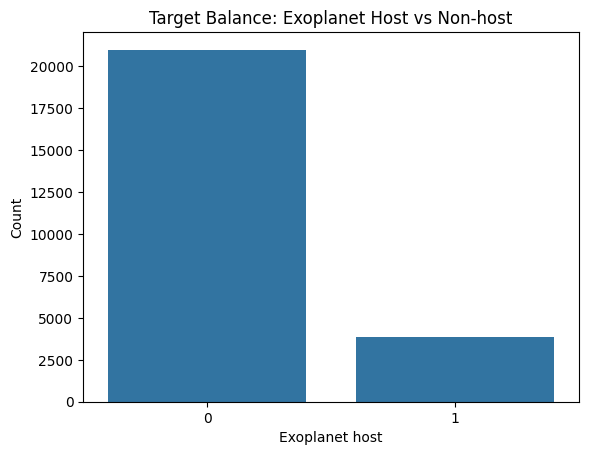

In [6]:
target_counts = stars_df["exoplanet_host"].value_counts()
target_share = stars_df["exoplanet_host"].value_counts(normalize=True).round(3)

print(target_counts)
print(target_share)

sns.countplot(data=stars_df, x="exoplanet_host")
plt.title("Target Balance: Exoplanet Host vs Non-host")
plt.xlabel("Exoplanet host")
plt.ylabel("Count")
plt.show()


## 5. Distribution analysis

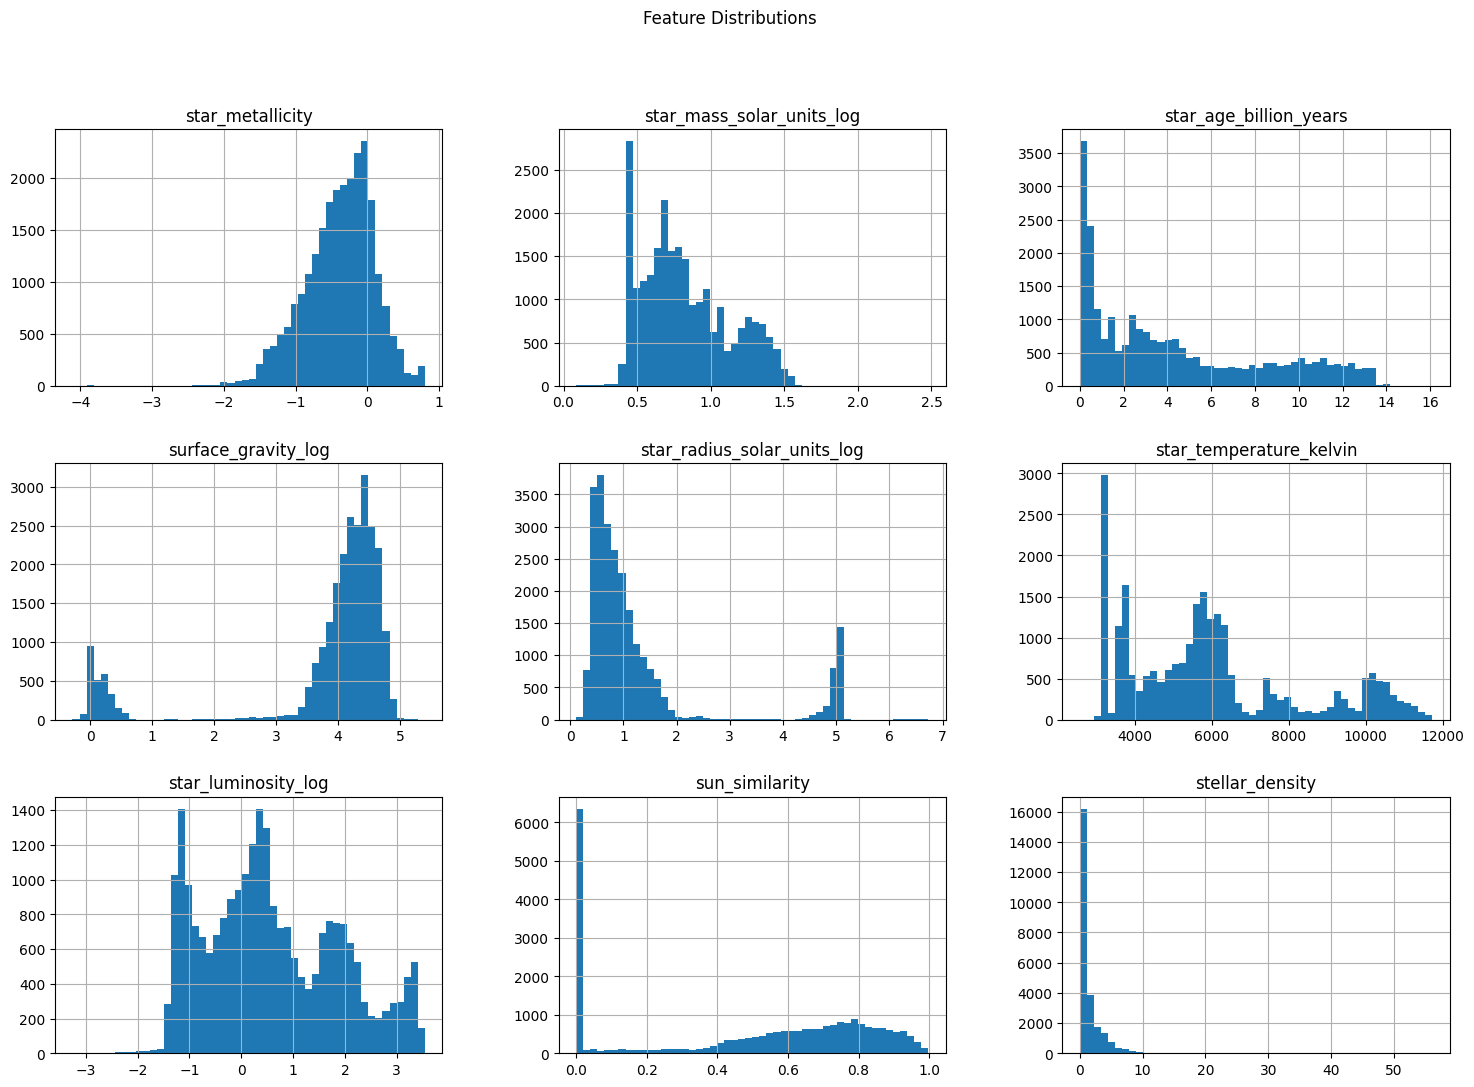

In [7]:
hist_features = [
    "star_metallicity",
    "star_mass_solar_units_log",
    "star_age_billion_years",
    "surface_gravity_log",
    "star_radius_solar_units_log",
    "star_temperature_kelvin",
    "star_luminosity_log",
    "sun_similarity",
    "stellar_density",
]

stars_df[hist_features].hist(bins=50, figsize=(18, 12))
plt.suptitle("Feature Distributions")
plt.show()


## 6. Correlation and mutual information

In [8]:
corr_matrix = stars_df.corr(numeric_only=True)
corr_with_target = corr_matrix["exoplanet_host"].sort_values(ascending=False)
corr_with_target


exoplanet_host                 1.000000
parallax_milliarcsec_log       0.560950
sun_similarity                 0.389744
star_metallicity               0.356911
parallax_milliarcsec           0.322723
surface_gravity_log            0.174735
star_age_billion_years         0.038594
stellar_density                0.018311
star_temperature_kelvin       -0.094164
star_radius_solar_units       -0.142459
star_radius_solar_units_log   -0.167631
hz_outer                      -0.186573
hz_width                      -0.186573
hz_inner                      -0.186573
star_luminosity_log           -0.192354
star_mass_solar_units_log     -0.196892
star_mass_solar_units         -0.208128
distance_parsecs              -0.310058
distance_parsecs_log          -0.504595
Name: exoplanet_host, dtype: float64

In [9]:
mi_X = stars_df[FINAL_FEATURES]
# .drop(columns=["stellar_type"])
mi_y = stars_df["exoplanet_host"]

mi_scores = mutual_info_classif(mi_X, mi_y, random_state=42)
mi_scores = pd.Series(mi_scores, index=mi_X.columns).sort_values(ascending=False)
mi_scores


star_metallicity               0.320913
star_age_billion_years         0.249866
star_mass_solar_units_log      0.248743
surface_gravity_log            0.234321
star_radius_solar_units_log    0.188080
star_temperature_kelvin        0.140520
sun_similarity                 0.131157
stellar_density                0.103339
star_luminosity_log            0.092228
dtype: float64

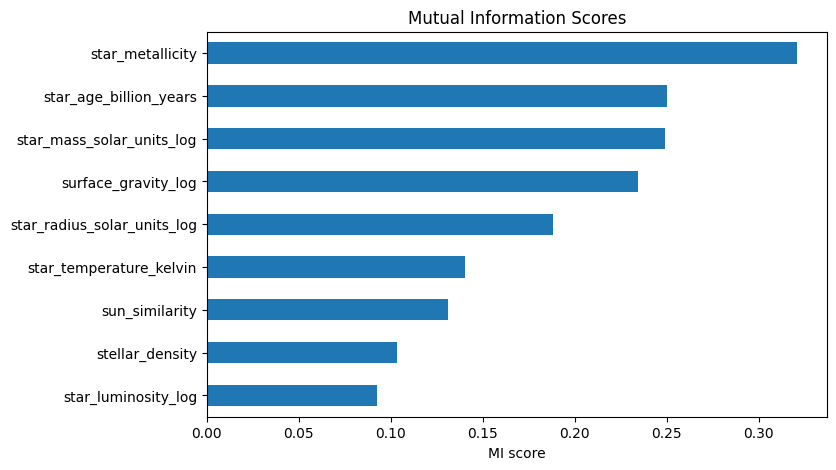

In [10]:
plt.figure(figsize=(8, 5))
mi_scores.sort_values().plot(kind="barh")
plt.title("Mutual Information Scores")
plt.xlabel("MI score")
plt.show()


## 7. Pairplot / scatter matrix

Use a sample to keep the plot readable and fast.

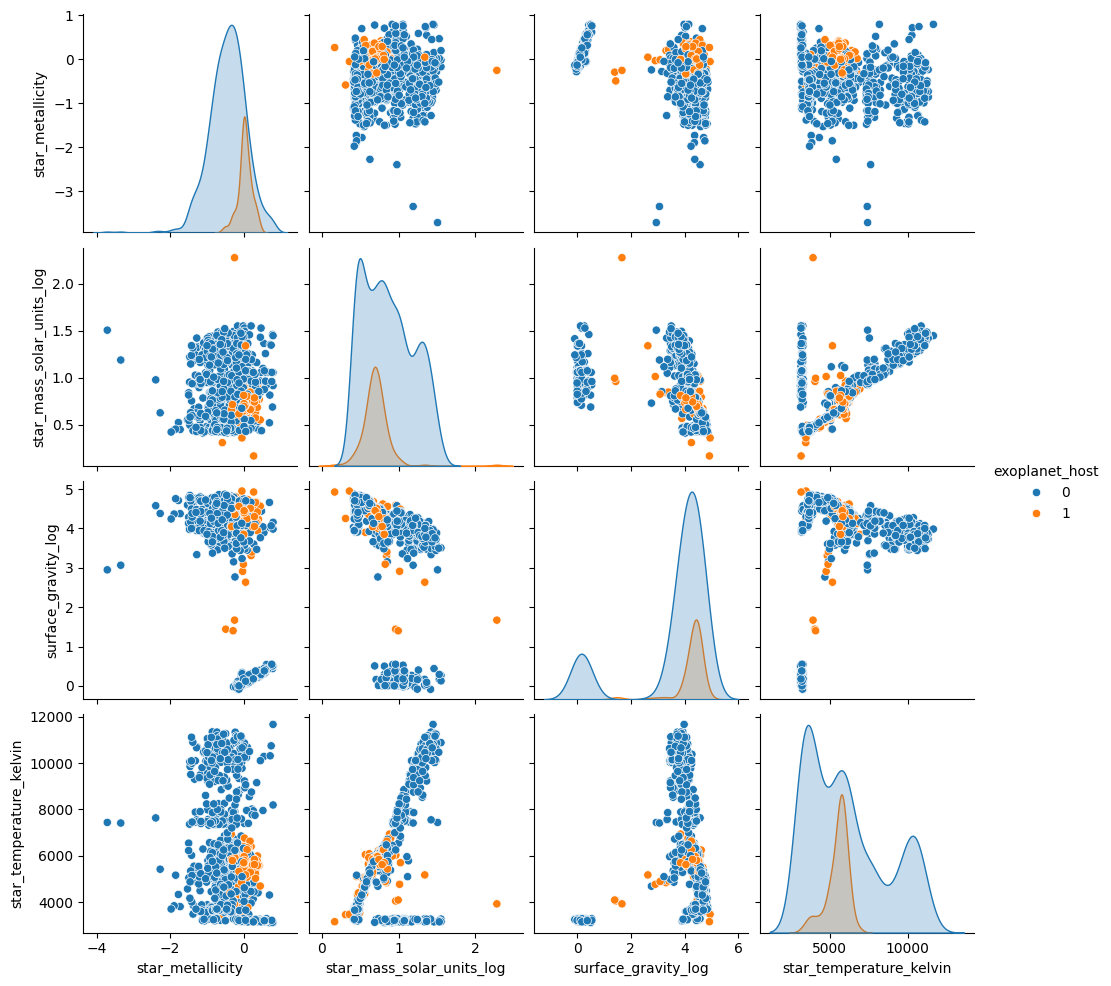

In [11]:
pairplot_features = [
    "star_metallicity",
    "star_mass_solar_units_log",
    "surface_gravity_log",
    "star_temperature_kelvin",
]

sns.pairplot(
    stars_df.sample(min(1000, len(stars_df)), random_state=42),
    vars=pairplot_features,
    hue="exoplanet_host",
)
plt.show()


## 8. Train/test split

Distance and parallax features are intentionally excluded from `FINAL_FEATURES` to reduce observational bias.

In [12]:
X = stars_df[FINAL_FEATURES]

y = stars_df["exoplanet_host"]

strat_X_train, strat_X_test, strat_y_train, strat_y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(strat_X_train.shape, strat_X_test.shape)


(19891, 9) (4973, 9)


## 9. Preprocessing pipeline

In [13]:
num_pipeline = Pipeline([
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessing = ColumnTransformer([
    ("num", num_pipeline, NUMERIC_FEATURES),
    # ("cat", cat_pipeline, CATEGORICAL_FEATURES),
])

preprocessing


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_na

## 10. Model comparison

In [14]:
neg_ratio = (strat_y_train == 0).sum() / (strat_y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        scale_pos_weight=neg_ratio,
        random_state=42,
        eval_metric="logloss",
        verbosity=0,
    ),
}

cv_scoring = ["roc_auc", "f1", "recall", "precision"]
results = {}
trained_pipelines = {}
cv_storage = {}
THRESHOLD = 0.70 # used for higher presicion for xgboost model

for model_name, model in models.items():
    print(f"{'=' * 50}")
    print(f"Training: {model_name}")
    print(f"{'=' * 50}")

    full_pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", model),
    ])

    cv_results = cross_validate(
        full_pipeline,
        strat_X_train,
        strat_y_train,
        cv=5,
        n_jobs=-1,
        scoring=cv_scoring,
        return_train_score=False,
    )

    full_pipeline.fit(strat_X_train, strat_y_train)

    y_pred_default = full_pipeline.predict(strat_X_test)
    y_proba = full_pipeline.predict_proba(strat_X_test)[:, 1]
    y_pred_threshold = (y_proba > THRESHOLD).astype(int)

    test_metrics = {
        "roc_auc": round(roc_auc_score(strat_y_test, y_proba), 4),
        "f1": round(f1_score(strat_y_test, y_pred_threshold), 4),
        "recall": round(recall_score(strat_y_test, y_pred_threshold), 4),
        "precision": round(precision_score(strat_y_test, y_pred_threshold), 4),
    }

    cv_metrics = {
        "cv_roc_auc_mean": round(cv_results["test_roc_auc"].mean(), 4),
        "cv_roc_auc_std": round(cv_results["test_roc_auc"].std(), 4),
        "cv_f1_mean": round(cv_results["test_f1"].mean(), 4),
        "cv_recall_mean": round(cv_results["test_recall"].mean(), 4),
        "cv_precision_mean": round(cv_results["test_precision"].mean(), 4),
    }

    cm = confusion_matrix(strat_y_test, y_pred_threshold)

    results[model_name] = {**test_metrics, **cv_metrics, "confusion_matrix": cm.tolist()}
    trained_pipelines[model_name] = full_pipeline
    cv_storage[model_name] = cv_results

    print("Test Results:")
    for metric_name, metric_value in test_metrics.items():
        print(f"{metric_name:12}: {metric_value}")

    print("Cross Validation:")
    for metric_name, metric_value in cv_metrics.items():
        print(f"{metric_name:24}: {metric_value}")

    print(f"Confusion Matrix at threshold {THRESHOLD}:{cm}")
    print("Classification Report at default threshold 0.5:")
    print(classification_report(strat_y_test, y_pred_default))


Training: Logistic Regression


Test Results:
roc_auc     : 0.934
f1          : 0.7172
recall      : 0.7956
precision   : 0.6529
Cross Validation:
cv_roc_auc_mean         : 0.9304
cv_roc_auc_std          : 0.0027
cv_f1_mean              : 0.6323
cv_recall_mean          : 0.8913
cv_precision_mean       : 0.49
Confusion Matrix at threshold 0.7:[[3873  327]
 [ 158  615]]
Classification Report at default threshold 0.5:
              precision    recall  f1-score   support

           0       0.97      0.83      0.90      4200
           1       0.49      0.88      0.63       773

    accuracy                           0.84      4973
   macro avg       0.73      0.86      0.76      4973
weighted avg       0.90      0.84      0.86      4973

Training: Random Forest
Test Results:
roc_auc     : 0.9898
f1          : 0.8189
recall      : 0.7193
precision   : 0.9504
Cross Validation:
cv_roc_auc_mean         : 0.9894
cv_roc_auc_std          : 0.0019
cv_f1_mean              : 0.8672
cv_recall_mean          : 0.8324
cv_precision_m

In [15]:
comparison_df = pd.DataFrame(results).T.drop(columns="confusion_matrix")
comparison_df


,roc_auc,f1,recall,precision,cv_roc_auc_mean,cv_roc_auc_std,cv_f1_mean,cv_recall_mean,cv_precision_mean
Logistic Regression,0.934,0.7172,0.7956,0.6529,0.9304,0.0027,0.6323,0.8913,0.49
Random Forest,0.9898,0.8189,0.7193,0.9504,0.9894,0.0019,0.8672,0.8324,0.9051
XGBoost,0.9913,0.9121,0.8991,0.9254,0.991,0.0015,0.9001,0.9266,0.8751


## 11. Final model: XGBoost

In [16]:
xgb_pipeline = trained_pipelines["XGBoost"]
xgb_model = xgb_pipeline.named_steps["model"]

feature_names = xgb_pipeline.named_steps["preprocessing"].get_feature_names_out()

feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

feature_importance


num__star_metallicity               0.343840
num__star_luminosity_log            0.263071
num__star_temperature_kelvin        0.100812
num__star_mass_solar_units_log      0.070475
num__sun_similarity                 0.048726
num__stellar_density                0.044599
num__surface_gravity_log            0.044553
num__star_age_billion_years         0.042531
num__star_radius_solar_units_log    0.041393
dtype: float32

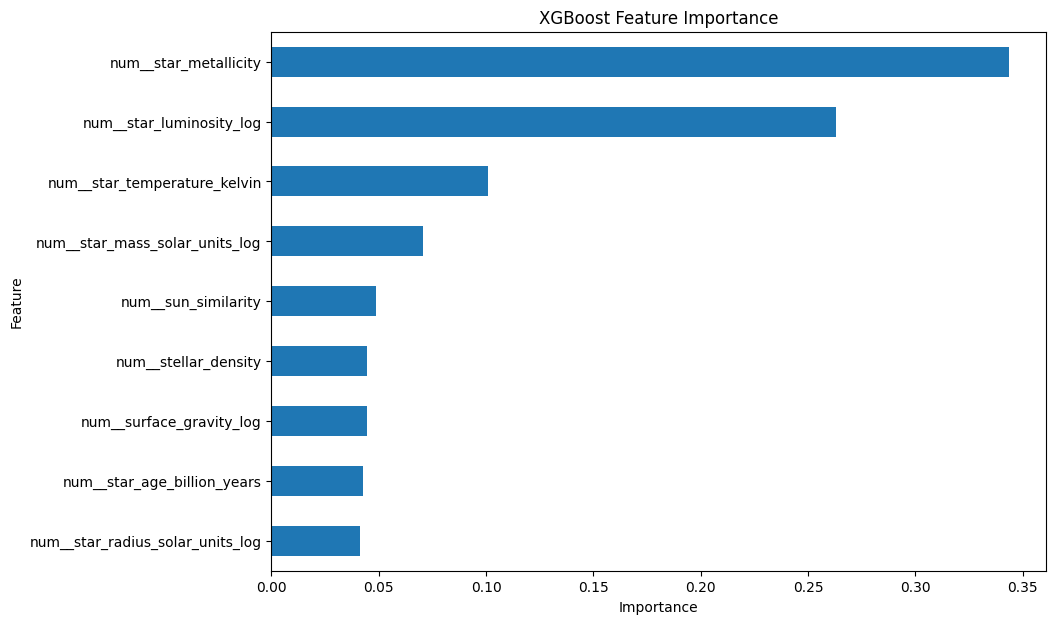

In [17]:
plt.figure(figsize=(10, 7))
feature_importance.sort_values().plot(kind="barh")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [18]:
# =====================================
# SHAP FOR XGBOOST PIPELINE
# =====================================

import shap
import pandas as pd
import matplotlib.pyplot as plt

xgb_pipeline = trained_pipelines["XGBoost"]

preprocessor = xgb_pipeline.named_steps["preprocessing"]
model = xgb_pipeline.named_steps["model"]

X_test_processed = preprocessor.transform(strat_X_test)

feature_names = preprocessor.get_feature_names_out()

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names
)

X_sample = X_test_processed.sample(
    min(500, len(X_test_processed)),
    random_state=42
)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

print("SHAP calculation completed")
print("Sample shape:", X_sample.shape)

SHAP calculation completed
Sample shape: (500, 9)


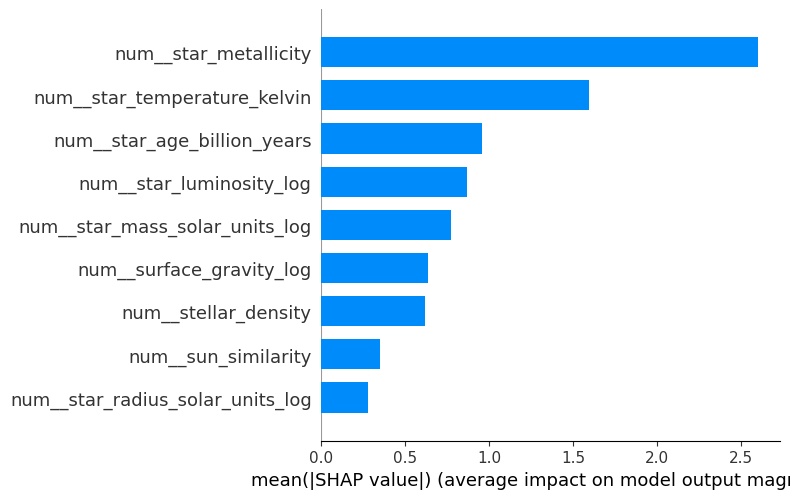

In [19]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

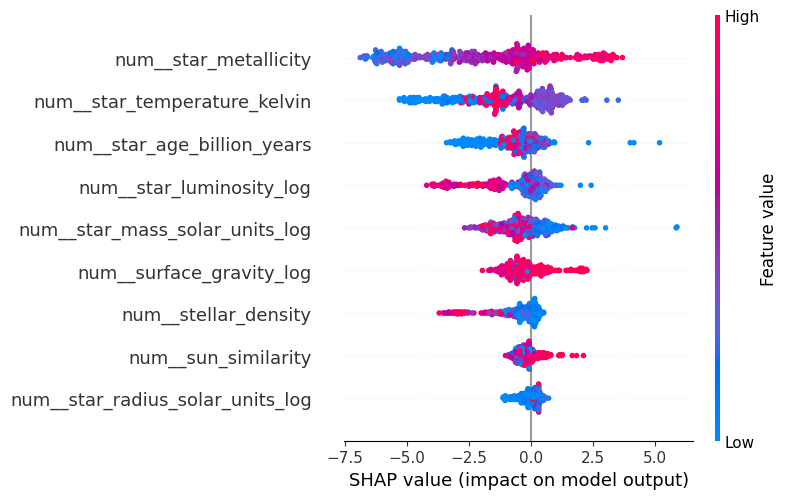

In [20]:
shap.summary_plot(
    shap_values,
    X_sample
)

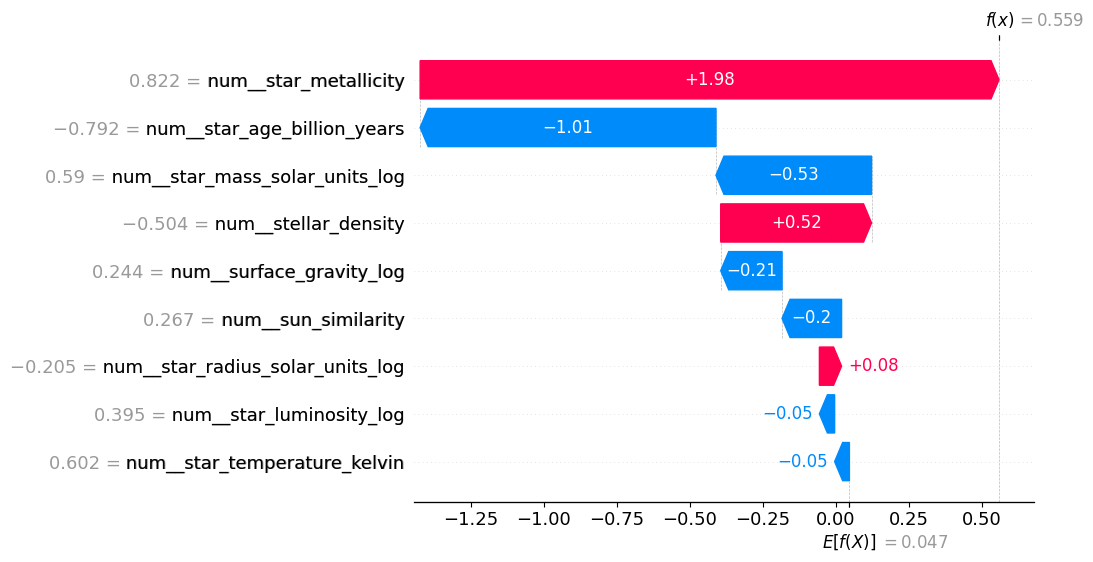

In [21]:
row = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[row],
        base_values=explainer.expected_value,
        data=X_sample.iloc[row],
        feature_names=X_sample.columns
    )
)

## 12. XGBoost evaluation plots

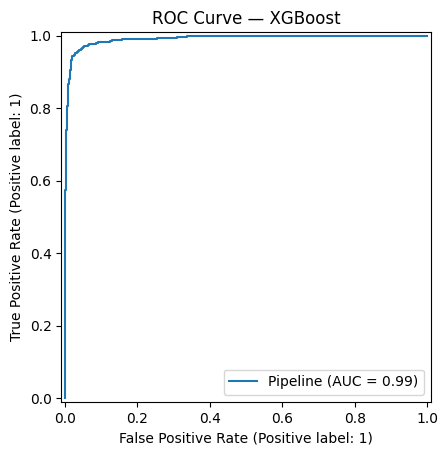

In [22]:
RocCurveDisplay.from_estimator(
    xgb_pipeline,
    strat_X_test,
    strat_y_test,
)
plt.title("ROC Curve — XGBoost")
plt.show()


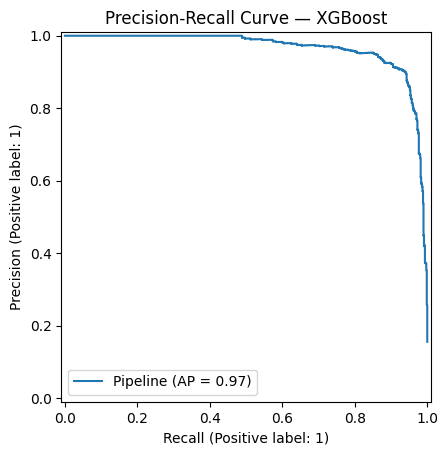

In [23]:
PrecisionRecallDisplay.from_estimator(
    xgb_pipeline,
    strat_X_test,
    strat_y_test,
)
plt.title("Precision-Recall Curve — XGBoost")
plt.show()


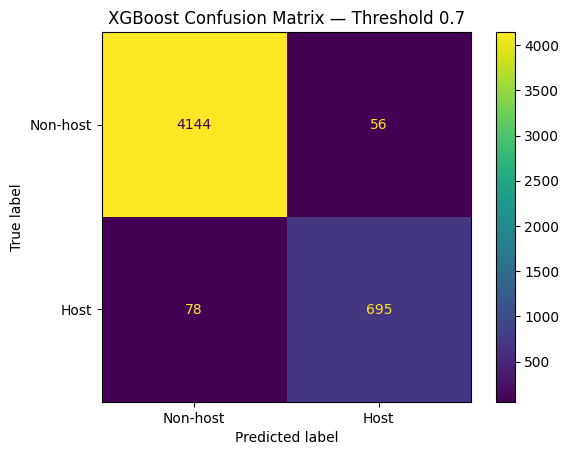

In [24]:
xgb_proba = xgb_pipeline.predict_proba(strat_X_test)[:, 1]
xgb_pred_threshold = (xgb_proba > THRESHOLD).astype(int)
xgb_cm = confusion_matrix(strat_y_test, xgb_pred_threshold)

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Non-host", "Host"],
).plot()
plt.title(f"XGBoost Confusion Matrix — Threshold {THRESHOLD}")
plt.show()


## 13. Prediction table for error analysis

In [25]:
xgb_results = strat_X_test.copy()
xgb_results["true_label"] = strat_y_test
xgb_results["host_probability"] = xgb_proba
xgb_results["prediction_threshold_0_7"] = xgb_pred_threshold

xgb_results.sort_values("host_probability", ascending=False).head(20)


,star_metallicity,star_mass_solar_units_log,star_age_billion_years,surface_gravity_log,star_radius_solar_units_log,star_temperature_kelvin,star_luminosity_log,sun_similarity,stellar_density,true_label,host_probability,prediction_threshold_0_7
143,0.4100,0.500775,1.620000,5.40000,0.463734,5400.00,-0.32941,0.7398,3.164881,1,0.999994,1
3556,0.2800,0.797507,0.160000,4.60000,0.815365,6234.00,0.33200,0.8164,0.609885,1,0.999988,1
860,0.1900,0.796606,0.024000,4.40000,0.810930,6140.00,0.29000,0.8433,0.623616,1,0.999987,1
45,0.2129,0.277632,1.000000,4.87177,0.262364,3293.74,-1.90658,0.5094,11.851852,1,0.999937,1
793,0.2700,0.292670,4.500000,4.86000,0.306013,3260.00,-1.83565,0.5113,7.410198,1,0.999937,1
1205,0.3360,0.227136,7.100000,4.95900,0.244905,3185.00,-2.14813,0.4598,11.933043,1,0.999932,1
1069,0.1400,0.266969,6.700000,4.89700,0.282167,3307.00,-1.95861,0.5273,8.832195,1,0.999929,1
3422,0.4860,0.909065,0.012100,4.14800,0.993252,5520.00,0.38202,0.6485,0.301649,1,0.999917,1
2675,-0.0300,0.378436,4.070000,4.83000,0.357674,3578.00,-1.54394,0.6197,5.785654,1,0.999900,1
446,0.3000,0.207014,3.000000,5.01000,0.216723,3075.00,-2.32873,0.4473,16.228625,1,0.999892,1


## 14. Sanity check: Sun-like star



In [26]:
sun_star = pd.DataFrame({
    "star_metallicity": [0.0],
    "star_mass_solar_units": [1.0],
    "star_age_billion_years": [4.6],
    "surface_gravity_log": [4.44],
    "star_radius_solar_units": [1.0],
    "star_temperature_kelvin": [5778],
    "star_luminosity_log": [0.0]
})

host_like_star = pd.DataFrame({
    "star_metallicity": [0.25],
    "star_mass_solar_units": [1.05],
    "star_age_billion_years": [5.0],
    "surface_gravity_log": [4.4],
    "star_radius_solar_units": [1.05],
    "star_temperature_kelvin": [5900],
    "star_luminosity_log": [0.1]
})

metal_poor_star = pd.DataFrame({
    "star_metallicity": [-1.5],
    "star_mass_solar_units": [0.85],
    "star_age_billion_years": [11.0],
    "surface_gravity_log": [4.5],
    "star_radius_solar_units": [0.9],
    "star_temperature_kelvin": [5400],
    "star_luminosity_log": [-0.2]
})

red_dwarf = pd.DataFrame({
    "star_metallicity": [-0.3],
    "star_mass_solar_units": [0.25],
    "star_age_billion_years": [8.0],
    "surface_gravity_log": [5.0],
    "star_radius_solar_units": [0.28],
    "star_temperature_kelvin": [3200],
    "star_luminosity_log": [-2.2]
})

unlikely_host_star = pd.DataFrame({
    "star_metallicity": [-2.5],
    "star_mass_solar_units": [0.18],
    "star_age_billion_years": [12.5],
    "surface_gravity_log": [5.1],
    "star_radius_solar_units": [0.2],
    "star_temperature_kelvin": [2900],
    "star_luminosity_log": [-3.0]
})

for name, star in {
    "Sun": sun_star,
    "Host-like": host_like_star,
    "Metal-poor": metal_poor_star,
    "Red dwarf": red_dwarf,
    "Unlikely": unlikely_host_star,
}.items():
    star = prepare_model_input(star)
    prob = xgb_pipeline.predict_proba(star)[0, 1]
    sun_prediction = int(prob > THRESHOLD)
    print(f"{name}: {prob:.4f}")
    print("Prediction:", sun_prediction)





Sun: 0.9985
Prediction: 1
Host-like: 0.9891
Prediction: 1
Metal-poor: 0.0007
Prediction: 0
Red dwarf: 0.9948
Prediction: 1
Unlikely: 0.2807
Prediction: 0


In [28]:
pred_proba = xgb_pipeline.predict_proba(strat_X_test)[:, 1]

print(pd.Series(pred_proba).describe())

count    4973.000000
mean        0.170359
std         0.347360
min         0.000002
25%         0.000123
50%         0.000838
75%         0.045179
max         0.999994
dtype: float64


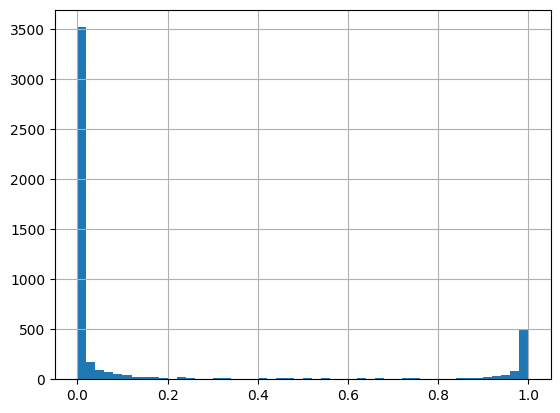

In [29]:
pd.Series(pred_proba).hist(bins=50)
plt.show()

## 15. Save final model

In [31]:
MODEL_PATH = PROJECT_ROOT/ "model" /"xgboost_exoplanet_model.pkl"
joblib.dump(xgb_pipeline, MODEL_PATH)
print(f"Saved model to: {MODEL_PATH}")


Saved model to: /Users/semyonsidorov/exoplanets_project/model/xgboost_exoplanet_model.pkl


In [32]:
import json

best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_pipeline   = trained_pipelines[best_model_name]
print(f"\nBest model: {best_model_name} (ROC-AUC: {results[best_model_name]['roc_auc']})")


metrics_to_save = {
    name: {k: v for k, v in metrics.items() if k != 'confusion_matrix'}
    for name, metrics in results.items()
}

metrics_to_save['best_model'] = best_model_name

with open(PROJECT_ROOT/'model'/'metrics.json', 'w') as f:
    json.dump(metrics_to_save, f, indent=4)
print(f"All metrics saved to model/metrics.json")


Best model: XGBoost (ROC-AUC: 0.9913)
All metrics saved to model/metrics.json
